In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import files
uploaded = files.upload()

Saving ecommerce_customer_data_large.csv to ecommerce_customer_data_large.csv


In [3]:
df = pd.read_csv("ecommerce_customer_data_large.csv")
df.head()

,Customer ID,Purchase Date,Product Category,Product Price,Quantity,Total Purchase Amount,Payment Method,Customer Age,Returns,Customer Name,Age,Gender,Churn
0,44605,2023-05-03 21:30:02,Home,177,1,2427,PayPal,31,1.0,John Rivera,31,Female,0
1,44605,2021-05-16 13:57:44,Electronics,174,3,2448,PayPal,31,1.0,John Rivera,31,Female,0
2,44605,2020-07-13 06:16:57,Books,413,1,2345,Credit Card,31,1.0,John Rivera,31,Female,0
3,44605,2023-01-17 13:14:36,Electronics,396,3,937,Cash,31,0.0,John Rivera,31,Female,0
4,44605,2021-05-01 11:29:27,Books,259,4,2598,PayPal,31,1.0,John Rivera,31,Female,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Customer ID            250000 non-null  int64  
 1   Purchase Date          250000 non-null  object 
 2   Product Category       250000 non-null  object 
 3   Product Price          250000 non-null  int64  
 4   Quantity               250000 non-null  int64  
 5   Total Purchase Amount  250000 non-null  int64  
 6   Payment Method         250000 non-null  object 
 7   Customer Age           250000 non-null  int64  
 8   Returns                202618 non-null  float64
 9   Customer Name          250000 non-null  object 
 10  Age                    250000 non-null  int64  
 11  Gender                 250000 non-null  object 
 12  Churn                  250000 non-null  int64  
dtypes: float64(1), int64(7), object(5)
memory usage: 24.8+ MB


In [5]:
df.isnull().sum()

,0
Customer ID,0
Purchase Date,0
Product Category,0
Product Price,0
Quantity,0
Total Purchase Amount,0
Payment Method,0
Customer Age,0
Returns,47382
Customer Name,0


In [6]:
df["Returns"] = df["Returns"].fillna(0)

In [7]:
df = df.drop(columns=["Customer Age"])

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 12 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Customer ID            250000 non-null  int64  
 1   Purchase Date          250000 non-null  object 
 2   Product Category       250000 non-null  object 
 3   Product Price          250000 non-null  int64  
 4   Quantity               250000 non-null  int64  
 5   Total Purchase Amount  250000 non-null  int64  
 6   Payment Method         250000 non-null  object 
 7   Returns                250000 non-null  float64
 8   Customer Name          250000 non-null  object 
 9   Age                    250000 non-null  int64  
 10  Gender                 250000 non-null  object 
 11  Churn                  250000 non-null  int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 22.9+ MB


In [10]:
df["Spending Level"] = pd.cut(df["Total Purchase Amount"],
                              bins=[0,100,500,1000,5000],
                              labels=["Low","Medium","High","Very High"])

In [11]:
df.head()

,Customer ID,Purchase Date,Product Category,Product Price,Quantity,Total Purchase Amount,Payment Method,Returns,Customer Name,Age,Gender,Churn,Spending Level
0,44605,2023-05-03 21:30:02,Home,177,1,2427,PayPal,1.0,John Rivera,31,Female,0,Very High
1,44605,2021-05-16 13:57:44,Electronics,174,3,2448,PayPal,1.0,John Rivera,31,Female,0,Very High
2,44605,2020-07-13 06:16:57,Books,413,1,2345,Credit Card,1.0,John Rivera,31,Female,0,Very High
3,44605,2023-01-17 13:14:36,Electronics,396,3,937,Cash,0.0,John Rivera,31,Female,0,High
4,44605,2021-05-01 11:29:27,Books,259,4,2598,PayPal,1.0,John Rivera,31,Female,0,Very High


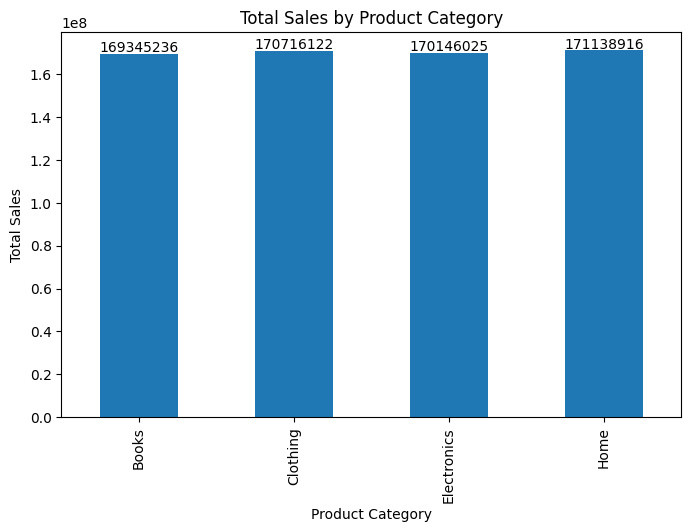

In [17]:
category_sales = df.groupby("Product Category")["Total Purchase Amount"].sum()

ax = category_sales.plot(kind="bar", figsize=(8,5))

plt.title("Total Sales by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Sales")

## added numbers on top of bars
for i, v in enumerate(category_sales):
    ax.text(i, v + 1000000, str(v), ha='center')

    plt.savefig("product_category_sales.png")

plt.show()

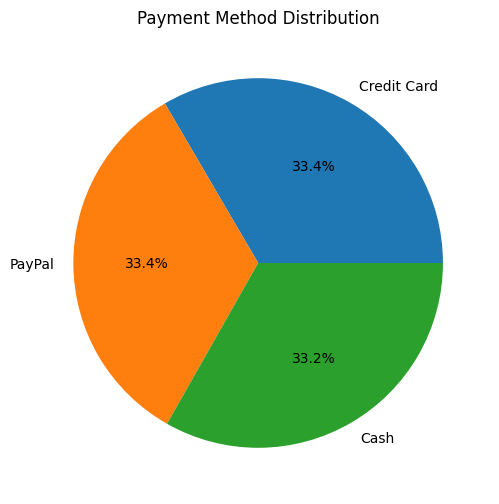

In [18]:
payment_method = df["Payment Method"].value_counts()

payment_method.plot(kind="pie", autopct="%1.1f%%", figsize=(6,6))

plt.title("Payment Method Distribution")
plt.ylabel("")

plt.savefig("payment_method_distribution.png")  # save chart

plt.show()



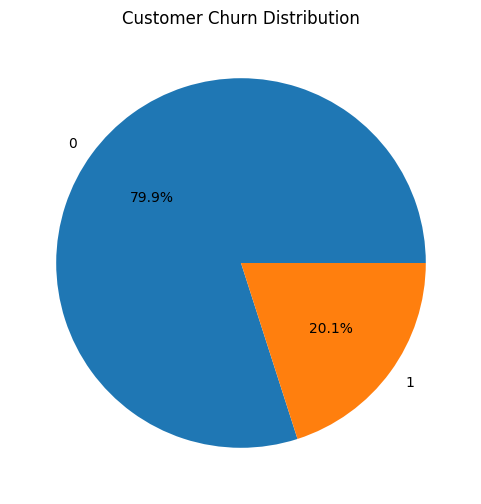

In [19]:
churn_counts = df["Churn"].value_counts()

ax = churn_counts.plot(kind="pie", autopct="%1.1f%%", figsize=(6,6))

plt.title("Customer Churn Distribution")
plt.ylabel("")

# save chart
plt.savefig("customer_churn_distribution.png")

plt.show()

In [21]:
df["Age Group"] = pd.cut(df["Age"],
                         bins=[18,25,35,45,60],
                         labels=["18-25","26-35","36-45","46-60"])

In [22]:
df.head()

,Customer ID,Purchase Date,Product Category,Product Price,Quantity,Total Purchase Amount,Payment Method,Returns,Customer Name,Age,Gender,Churn,Spending Level,Age Group
0,44605,2023-05-03 21:30:02,Home,177,1,2427,PayPal,1.0,John Rivera,31,Female,0,Very High,26-35
1,44605,2021-05-16 13:57:44,Electronics,174,3,2448,PayPal,1.0,John Rivera,31,Female,0,Very High,26-35
2,44605,2020-07-13 06:16:57,Books,413,1,2345,Credit Card,1.0,John Rivera,31,Female,0,Very High,26-35
3,44605,2023-01-17 13:14:36,Electronics,396,3,937,Cash,0.0,John Rivera,31,Female,0,High,26-35
4,44605,2021-05-01 11:29:27,Books,259,4,2598,PayPal,1.0,John Rivera,31,Female,0,Very High,26-35


/tmp/ipykernel_639/322559687.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_sales = df.groupby("Age Group")["Total Purchase Amount"].sum()


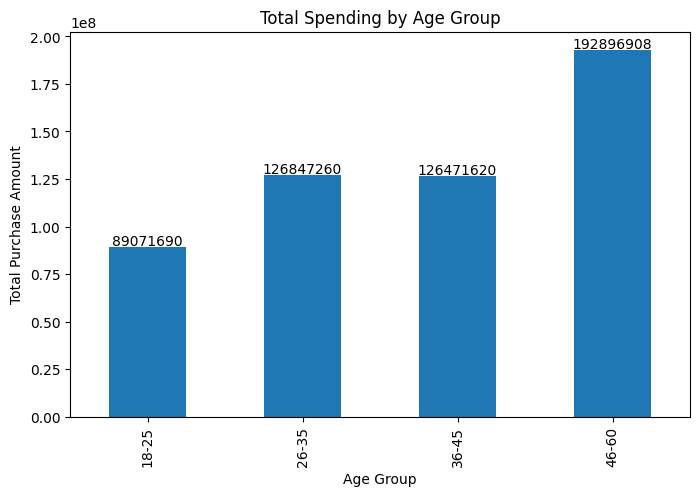

In [23]:
age_sales = df.groupby("Age Group")["Total Purchase Amount"].sum()

ax = age_sales.plot(kind="bar", figsize=(8,5))

plt.title("Total Spending by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Total Purchase Amount")

for i, v in enumerate(age_sales):
    ax.text(i, v + 1000000, str(v), ha='center')

plt.savefig("age_group_sales.png")

plt.show()

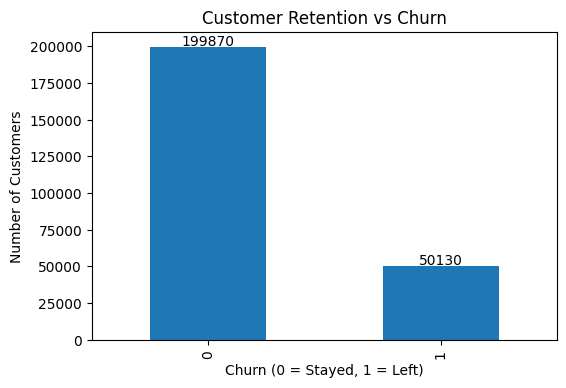

In [24]:
retention = df["Churn"].value_counts()

ax = retention.plot(kind="bar", figsize=(6,4))

plt.title("Customer Retention vs Churn")
plt.xlabel("Churn (0 = Stayed, 1 = Left)")
plt.ylabel("Number of Customers")

for i, v in enumerate(retention):
    ax.text(i, v + 1000, str(v), ha='center')

plt.savefig("customer_retention_analysis.png")

plt.show()

## Business Recommendation for Alfido Tech

1. Focus Marketing on High-Revenue Product Categories  
Analysis shows certain product categories generate the highest sales. Alfido Tech should increase promotions and marketing campaigns around these categories to maximize revenue.

2. Promote Preferred Payment Methods  
Customers show clear preferences for certain payment methods. Offering cashback or small discounts for these methods could increase customer conversions.

3. Reduce Customer Churn with Loyalty Programs  
A portion of customers stop purchasing. Implementing loyalty rewards, discounts for repeat customers, or membership programs could help retain customers.

4. Target High-Spending Age Groups  
Some age segments contribute more to total sales. Alfido Tech should design targeted marketing campaigns and personalized recommendations for these customer groups.

5. Improve Customer Engagement  
Sending personalized emails, product recommendations, and seasonal offers can improve customer engagement and increase long-term retention.